In [ ]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

# Your specific path
zip_path = '/content/drive/MyDrive/PlotQA-Stemsight/horizontal_bars_sample.zip'
extract_path = '/content/dataset_hbar'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"✅ Extracted to {extract_path}")
!pip install -q transformers datasets sentencepiece accelerate

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted to /content/dataset_hbar


In [ ]:
import json
from PIL import Image
from torch.utils.data import Dataset
from pathlib import Path

class HorizontalDonutDataset(Dataset):
    def __init__(self, dataset_path, processor, max_length=512, limit=10000):
        self.dataset_path = Path(dataset_path) / "train"
        self.processor = processor
        self.max_length = max_length

        metadata_path = self.dataset_path / "metadata.jsonl"

        if not metadata_path.exists():
            raise FileNotFoundError(f"❌ Missing metadata.jsonl at: {metadata_path}")

        with open(metadata_path, "r") as f:
            self.lines = f.readlines()[:limit]
        print(f"📋 Loaded {len(self.lines)} samples for Horizontal Bar training.")

    def __len__(self):
        return len(self.lines)

    def __getitem__(self, idx):
        line = json.loads(self.lines[idx])
        image_path = self.dataset_path / line["file_name"]
        image = Image.open(image_path).convert("RGB")

        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        target_sequence = f"<s_chartqa>{line['ground_truth']}</s_chartqa>"

        labels = self.processor.tokenizer(
            target_sequence,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids

        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values.squeeze(), "labels": labels.squeeze()}

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel, TrainingArguments, Trainer

# 1. Load Model & Processor (Starting from VBAR Master)
device = "cuda" if torch.cuda.is_available() else "cpu"
master_vbar_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"

processor = DonutProcessor.from_pretrained(master_vbar_path)
model = VisionEncoderDecoderModel.from_pretrained(
    master_vbar_path,
    tie_word_embeddings=False
).to(device)

# 2. Prepare Dataset (10k Samples)
train_dataset = HorizontalDonutDataset("/content/dataset_hbar", processor, limit=10000)

# 🚀 CRITICAL FIX: Create a small validation subset (200 samples)
# This ensures "Validation Loss" appears INSTANTLY without freezing the training.
val_subset = torch.utils.data.Subset(train_dataset, range(0, 200))

# 3. Training Arguments (Optimized for Fast Feedback)
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    num_train_epochs=3,            # As requested: 3 Epochs
    weight_decay=0.01,

    # --- FEEDBACK SETTINGS ---
    logging_steps=10,              # Update Training Loss every 10 steps
    logging_first_step=True,       # Show results IMMEDIATELY at Step 1
    eval_strategy="steps",
    eval_steps=100,                # Show Validation Loss every 100 steps

    # --- PERFORMANCE ---
    fp16=True,                     # Use T4 GPU Speedup
    save_steps=500,                # Save every 500 steps
    save_total_limit=2,
    report_to="none",
    load_best_model_at_end=False   # Keep it fast
)

# 4. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_subset        # Fast validation on subset
)

print("🚀 Starting Training... Results will appear in the table in seconds.")
trainer.train()

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


📋 Loaded 10000 samples for Horizontal Bar training.
🚀 Starting Training... Results will appear in the table in seconds.


Step,Training Loss,Validation Loss
100,0.352604,0.057357
200,0.172445,0.040945
300,0.161842,0.030025
400,0.135655,0.021378
500,0.127927,0.020767
600,0.130604,0.013847
700,0.119647,0.010233
800,0.091132,0.009002
900,0.060498,0.007931
1000,0.093134,0.007778


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3750, training_loss=0.18745066826343537, metrics={'train_runtime': 4838.0893, 'train_samples_per_second': 6.201, 'train_steps_per_second': 0.775, 'total_flos': 1.594731338661888e+19, 'train_loss': 0.18745066826343537, 'epoch': 3.0})

Mounted at /content/drive
⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:01<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving 5583.png to 5583.png
Processing file: "5583.png"


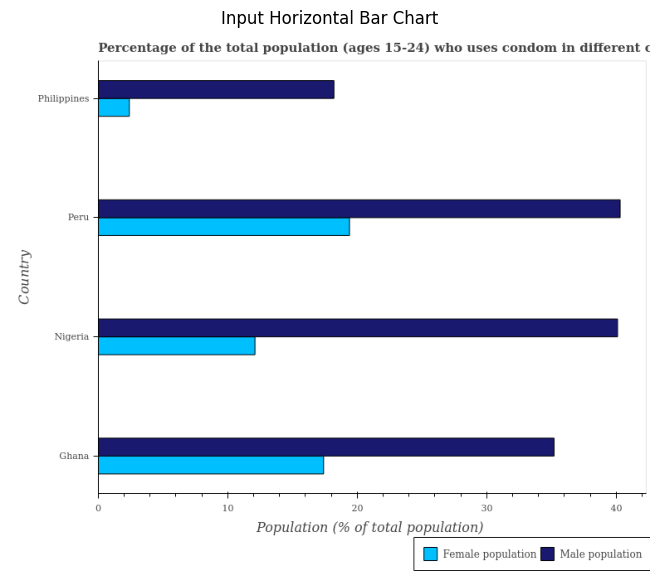

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Percentage of the total population (ages 15-24) who uses condom in different countries'. The x-axis shows Population (% of total population) and the y-axis shows Country."}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{</s_chartqa>{</s_chartqa>{</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving 5578.png to 5578.png
Processing file: "5578.png"


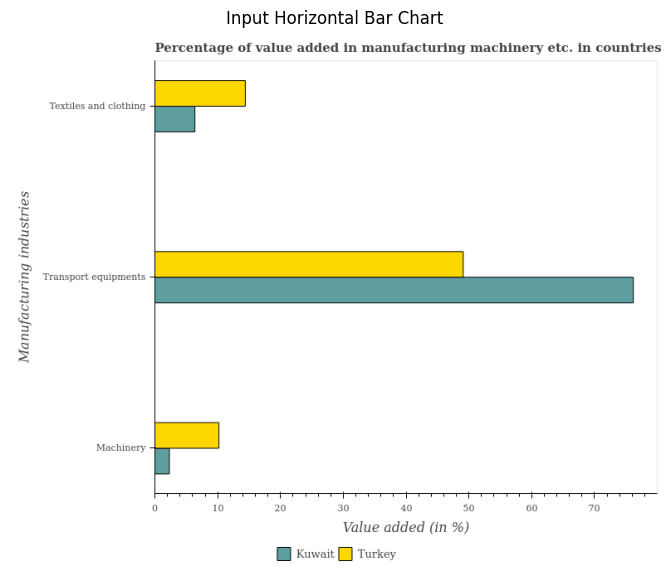

🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Percentage of value added in manufacturing machinery etc. in countries'. The x-axis shows Value added (in %) and the y-axis shows Manufacturing industries."}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_chart</s_
------------------

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving 5664.png to 5664.png
Processing file: "5664.png"


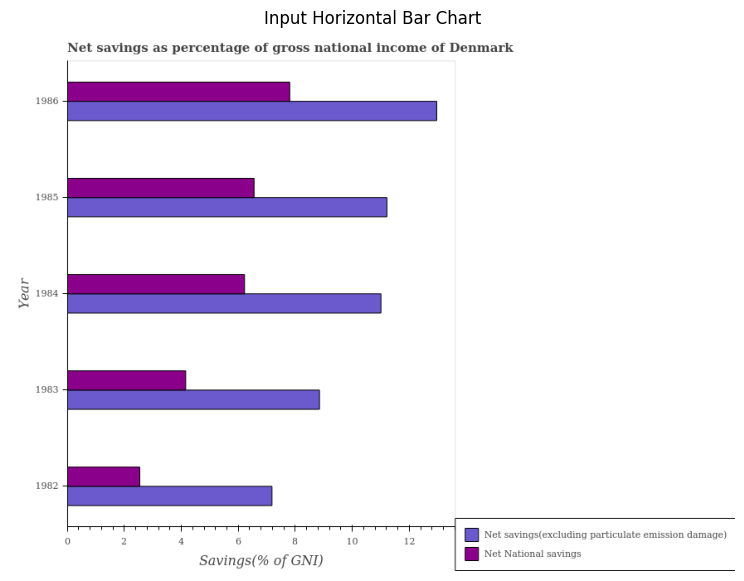

🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Net savings as percentage of gross national income of Denmark'. The x-axis shows Savings(% of GNI) and the y-axis shows Year."}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa></s_chartqa></s_chartqa></s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>chartqa>char

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving 5737.png to 5737.png
Processing file: "5737.png"


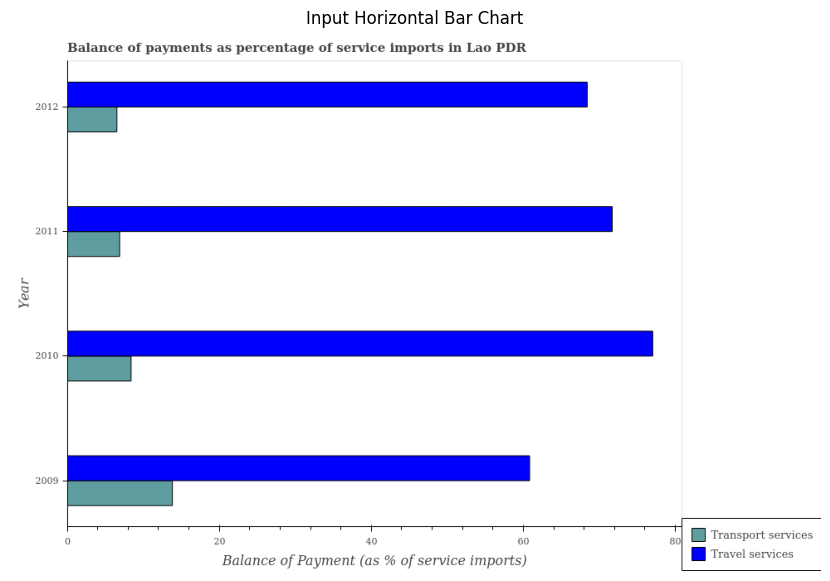

🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Balance of payments as percentage of service imports in Lao PDR'. The x-axis shows Balance of Payment (as % of service imports) and the y-axis shows Year."}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa></s_chartqa></s_chartqa></s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_
-------------------

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving 5802.png to 5802.png
Processing file: "5802.png"


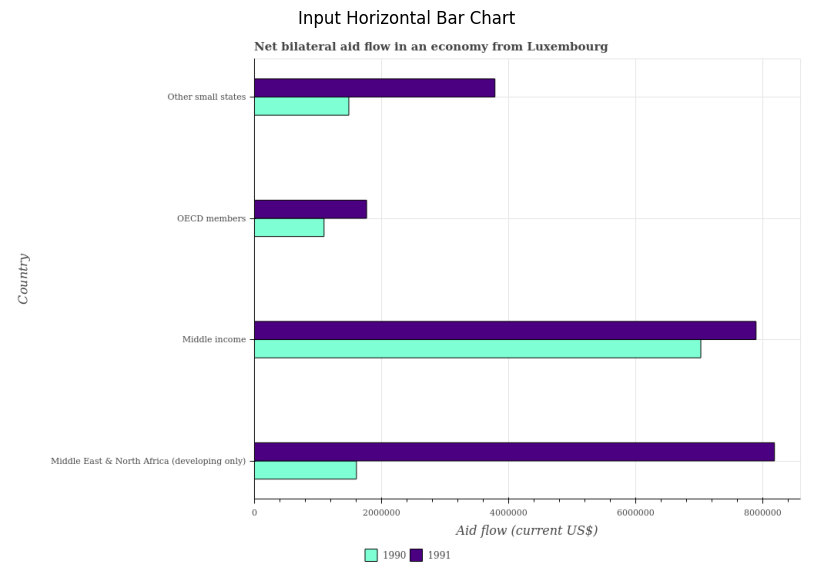

🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Net bilateral aid flow in an economy from Luxembourg'. The x-axis shows Aid flow (current US$) and the y-axis shows Country."}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart_chart

In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving Example-of-Simple-Horizontal-Bar-Graph.png to Example-of-Simple-Horizontal-Bar-Graph.png
Processing file: "Example-of-Simple-Horizontal-Bar-Graph.png"


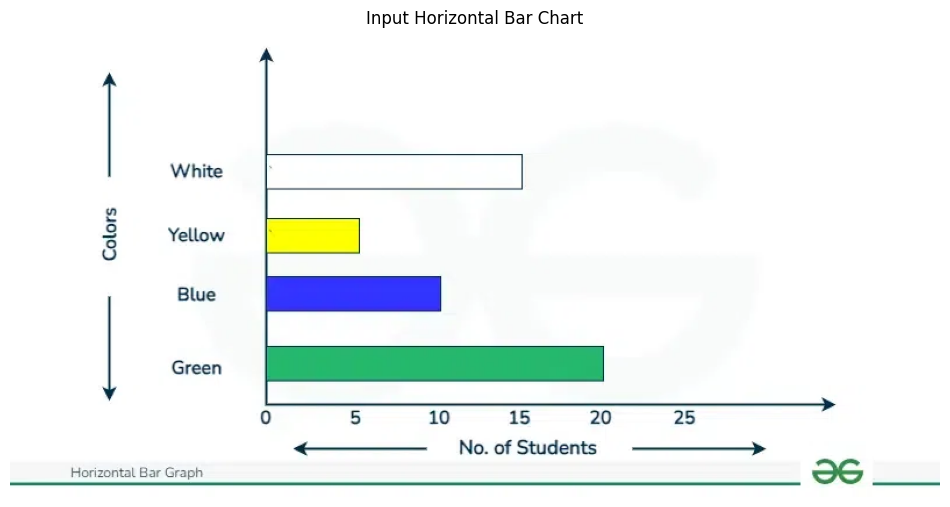

🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Value added by the y-axis shows Years."}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>{"}</s_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa>_chartqa
---------------------------



In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Processor from Master...
⏳ Loading Model Weights from /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving Increasing-Efficiency-Drivers-With-Horizontal-Bar-Chart.png to Increasing-Efficiency-Drivers-With-Horizontal-Bar-Chart (1).png
Processing file: "Increasing-Efficiency-Drivers-With-Horizontal-Bar-Chart (1).png"


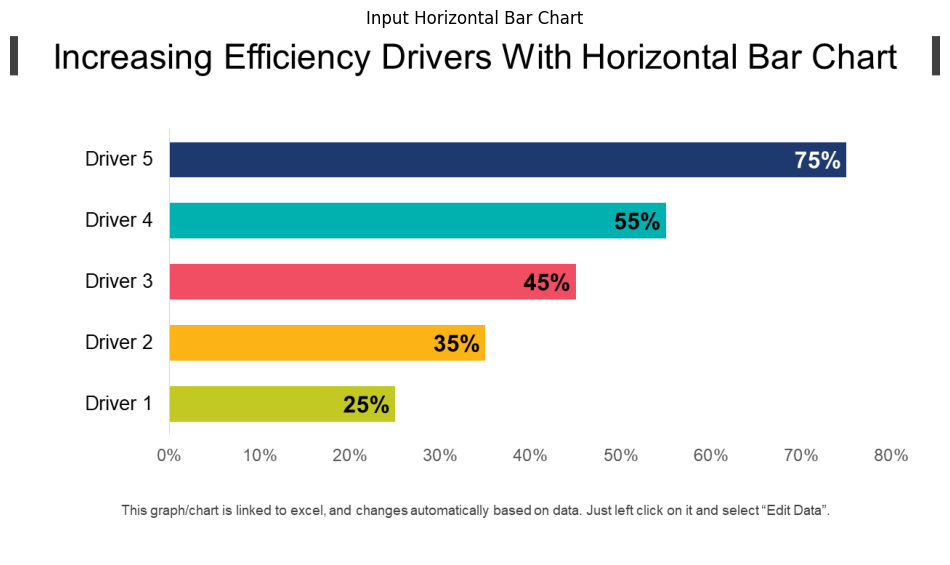

🚀 Model generating summary...

📊 --- ANALYSIS RESULT ---
{"gt-parse">: "This is a hbar categorical titled 'Increasing in efficiency. ship/savings within Herzovofficial Bar % of cohori."}</b><axis shows Type groups index(% on female labor force).
---------------------------



In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT CHECK ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. CONFIGURATION & PATHS ---
# Absolute paths ensure the library knows these are local folders
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Processor from Master...")
# local_files_only=True ensures it doesn't look for a repo online
processor = DonutProcessor.from_pretrained(
    master_path,
    local_files_only=True
)

print(f"⏳ Loading Model Weights from {checkpoint_path}...")
model = VisionEncoderDecoderModel.from_pretrained(
    checkpoint_path,
    local_files_only=True
).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. INFERENCE & VISUALIZATION FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and display the image
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(12, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Input Horizontal Bar Chart")
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    # Generate summary
    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            early_stopping=True,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # Decode and clean
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    clean_summary = re.sub(r"<.*?>", "", sequence, count=1).strip()

    print("\n📊 --- ANALYSIS RESULT ---")
    print(clean_summary)
    print("---------------------------\n")

# --- 4. UPLOAD IMAGE FROM COMPUTER ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Processing file: "{filename}"')
    run_hbar_prediction(filename)

⏳ Loading Models...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload your chart to get the summary:


Saving Increasing-Efficiency-Drivers-With-Horizontal-Bar-Chart.png to Increasing-Efficiency-Drivers-With-Horizontal-Bar-Chart (2).png


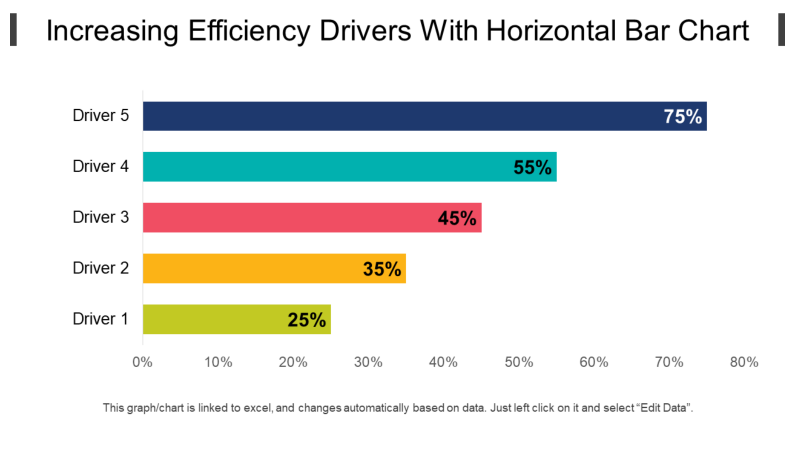

🚀 Model generating summary...

📊 --- SPECTRA FINAL ANALYSIS ---
This is a Horizontal Bar Chart titled 'Increasing in efficiency Drivers with Horizontal Bar        and the y-axis shows Sectors (current US$).
----------------------------------



In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. PATHS ---
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Models...")
processor = DonutProcessor.from_pretrained(master_path, local_files_only=True)
model = VisionEncoderDecoderModel.from_pretrained(checkpoint_path, local_files_only=True).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. CLEANING & INFERENCE FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and Display
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=150,               # Chhota limit taaki loop na kare
            early_stopping=True,
            no_repeat_ngram_size=3,       # Repetition control
            repetition_penalty=1.5,       # Loop breaker
            num_beams=2,                  # Better quality
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            return_dict_in_generate=True,
        )

    # Decode
    sequence = processor.batch_decode(outputs.sequences)[0]

    # --- DYNAMITE CLEANING LOGIC ---
    # Sirf "gt_parse" ke andar wali string nikalne ke liye
    match = re.search(r'"gt_parse":\s*"(.*?)"', sequence)

    if match:
        clean_summary = match.group(1)
    else:
        # Fallback agar regex fail ho
        clean_summary = re.sub(r'<.*?>', '', sequence).strip()
        clean_summary = clean_summary.replace('{"gt_parse": "', '').replace('"}', '')

    # Final "Human-Friendly" touch
    clean_summary = clean_summary.replace("hbar categorical", "Horizontal Bar Chart")

    print("\n📊 --- SPECTRA FINAL ANALYSIS ---")
    print(clean_summary)
    print("----------------------------------\n")

# --- 4. INTERACTIVE UPLOAD ---
print("📤 Upload your chart to get the summary:")
uploaded = files.upload()

for filename in uploaded.keys():
    run_hbar_prediction(filename)

⏳ Loading Models...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload your chart to get the summary:


Saving 5703.png to 5703.png


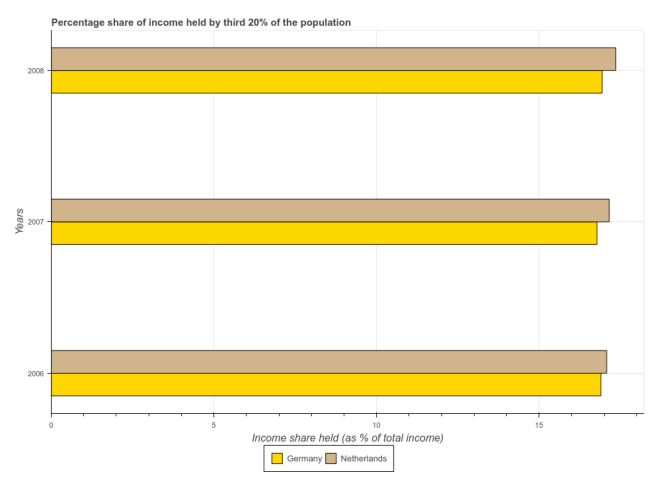

🚀 Model generating summary...

📊 --- SPECTRA FINAL ANALYSIS ---
This is a Horizontal Bar Chart titled 'Percentage share of income held by third 20% of the population'. The x-axis shows Income share held (as % of total income) and the y-axim shows Years.
----------------------------------



In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. PATHS ---
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Models...")
processor = DonutProcessor.from_pretrained(master_path, local_files_only=True)
model = VisionEncoderDecoderModel.from_pretrained(checkpoint_path, local_files_only=True).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. CLEANING & INFERENCE FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and Display
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=150,               # Chhota limit taaki loop na kare
            early_stopping=True,
            no_repeat_ngram_size=3,       # Repetition control
            repetition_penalty=1.5,       # Loop breaker
            num_beams=2,                  # Better quality
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            return_dict_in_generate=True,
        )

    # Decode
    sequence = processor.batch_decode(outputs.sequences)[0]

    # --- DYNAMITE CLEANING LOGIC ---
    # Sirf "gt_parse" ke andar wali string nikalne ke liye
    match = re.search(r'"gt_parse":\s*"(.*?)"', sequence)

    if match:
        clean_summary = match.group(1)
    else:
        # Fallback agar regex fail ho
        clean_summary = re.sub(r'<.*?>', '', sequence).strip()
        clean_summary = clean_summary.replace('{"gt_parse": "', '').replace('"}', '')

    # Final "Human-Friendly" touch
    clean_summary = clean_summary.replace("hbar categorical", "Horizontal Bar Chart")

    print("\n📊 --- SPECTRA FINAL ANALYSIS ---")
    print(clean_summary)
    print("----------------------------------\n")

# --- 4. INTERACTIVE UPLOAD ---
print("📤 Upload your chart to get the summary:")
uploaded = files.upload()

for filename in uploaded.keys():
    run_hbar_prediction(filename)

⏳ Loading Models...


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload your chart to get the summary:


Saving 6430.png to 6430.png


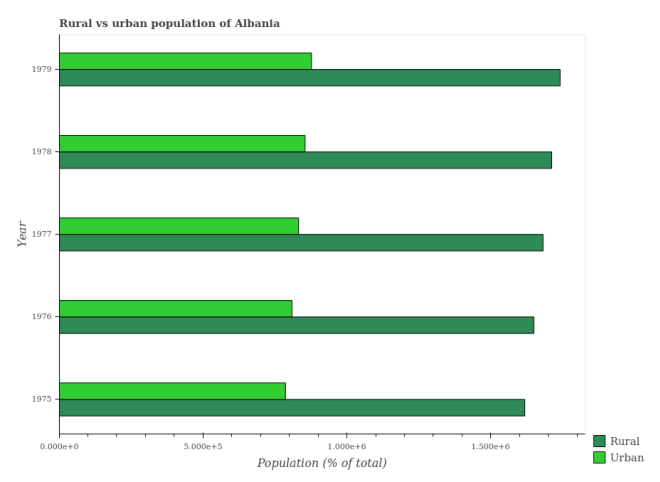

🚀 Model generating summary...

📊 --- SPECTRA FINAL ANALYSIS ---
This is a Horizontal Bar Chart titled 'Rural vs urban population of Albania'. The x-axis shows Population (% of total) and the y-axhi>{% of newborns.
----------------------------------



In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import matplotlib.pyplot as plt
import re
import os
from google.colab import files, drive

# --- 0. DRIVE MOUNT ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. PATHS ---
master_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_VBAR_Final")
checkpoint_path = os.path.abspath("/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750")

# --- 2. LOAD PROCESSOR & MODEL ---
device = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Loading Models...")
processor = DonutProcessor.from_pretrained(master_path, local_files_only=True)
model = VisionEncoderDecoderModel.from_pretrained(checkpoint_path, local_files_only=True).to(device)

print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 3. CLEANING & INFERENCE FUNCTION ---
def run_hbar_prediction(image_path):
    # Load and Display
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # Prepare inputs
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

    print("🚀 Model generating summary...")
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=150,               # Chhota limit taaki loop na kare
            early_stopping=True,
            no_repeat_ngram_size=3,       # Repetition control
            repetition_penalty=1.5,       # Loop breaker
            num_beams=2,                  # Better quality
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            return_dict_in_generate=True,
        )

    # Decode
    sequence = processor.batch_decode(outputs.sequences)[0]

    # --- DYNAMITE CLEANING LOGIC ---
    # Sirf "gt_parse" ke andar wali string nikalne ke liye
    match = re.search(r'"gt_parse":\s*"(.*?)"', sequence)

    if match:
        clean_summary = match.group(1)
    else:
        # Fallback agar regex fail ho
        clean_summary = re.sub(r'<.*?>', '', sequence).strip()
        clean_summary = clean_summary.replace('{"gt_parse": "', '').replace('"}', '')

    # Final "Human-Friendly" touch
    clean_summary = clean_summary.replace("hbar categorical", "Horizontal Bar Chart")

    print("\n📊 --- SPECTRA FINAL ANALYSIS ---")
    print(clean_summary)
    print("----------------------------------\n")

# --- 4. INTERACTIVE UPLOAD ---
print("📤 Upload your chart to get the summary:")
uploaded = files.upload()

for filename in uploaded.keys():
    run_hbar_prediction(filename)

In [ ]:
pip install torch transformers Pillow sentencepiece

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from google.colab import files

# 1. Paths define karo
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
checkpoint_path = "/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750"

# 2. Check karo ki folders exist karte hain ya nahi
if not os.path.exists(master_path) or not os.path.exists(checkpoint_path):
    print("❌ Error: Drive folders nahi mile! Check karo ki Drive mounted hai ya paths sahi hain.")
else:
    # 3. Zip the Processor (Master)
    print("📦 Zipping Processor (VBAR Final)...")
    !zip -r /content/processor_hbar.zip "{master_path}"

    # 4. Zip the Model Weights (HBAR Expert)
    print("📦 Zipping Model Weights (HBAR Expert)...")
    !zip -r /content/model_hbar.zip "{checkpoint_path}"

    # 5. Download to your Mac
    print("📥 Downloading to Mac... (Files thodi badi hain, wait karna)")
    if os.path.exists("/content/processor_hbar.zip"):
        files.download("/content/processor_hbar.zip")

    if os.path.exists("/content/model_hbar.zip"):
        files.download("/content/model_hbar.zip")

📦 Zipping Processor (VBAR Final)...
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/ (stored 0%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/model.safetensors (deflated 7%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/training_args.bin (deflated 53%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/tokenizer_config.json (deflated 48%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/tokenizer.json (deflated 74%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/processor_config.json (deflated 55%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/config.json (deflated 74%)
  adding: content/drive/MyDrive/STEM_Sight_VBAR_Final/generation_config.json (deflated 58%)
📦 Zipping Model Weights (HBAR Expert)...
  adding: content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750/ (stored 0%)
  adding: content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750/config.json (deflated 74%)
  adding: content/drive/MyDrive/STEM_Sight_HBAR_Expert_V

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🧠 Loading HBAR weights from: /content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2/checkpoint-3750/model.safetensors


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ STEM Sight Horizontal Expert ready on CUDA
📤 Upload a horizontal bar chart image to test:


Saving 5699.png to 5699.png


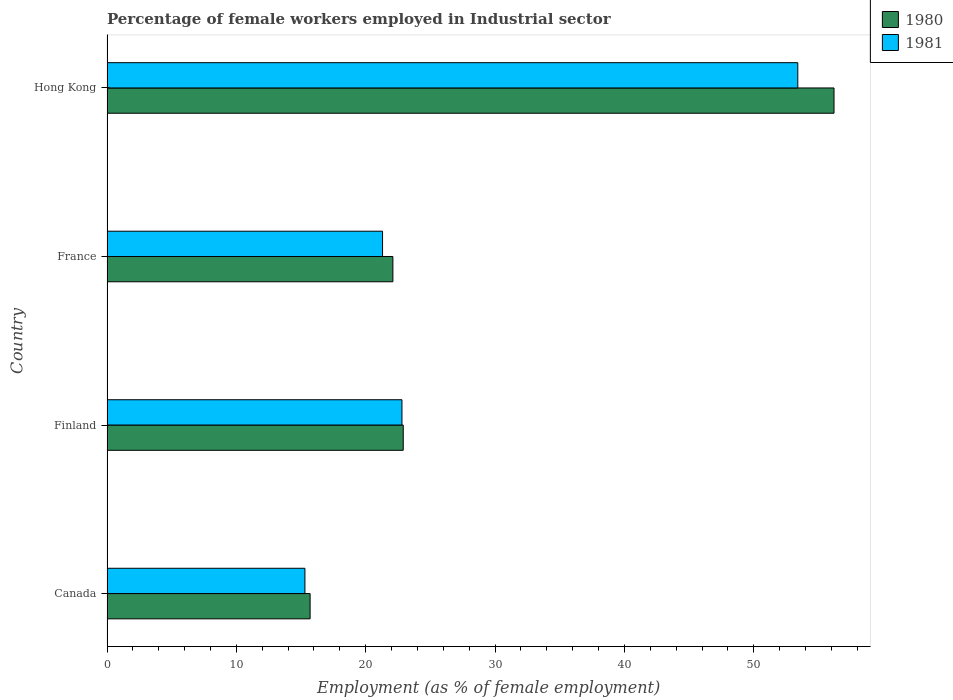


--- ANALYSIS RESULT ---
{"gt_parse": "This is a hbar categorical titled 'Percentage of female workers employed in Industrial sector'. The x-axis shows Employment (as % of total employers) and the y-axhi>= youth population."}{% of femal>==>= according to the y non-familierm."}\chartq>=low to secondary compet>_chertqa= only=lowly=high>=highty=lowti>= when a>= okay=lowtyears."k>= how-"chandise com>=howtqan>=,"}{x->mount>= yours_marke>=>=/ma>=yohqa>=|chart>s>fchartc>l>ssthan>{{current>sunders>ls{";chartqart{nnart{chartJan{",chartgnantcharte>charts_charttqa>—chartqandy->!{*chartqua>_charactes_chans_chams_scartqav_charg_charten_daran>_dan>_cartqap_charat%_charact>_can>_man_non_charity_charance>_cana>_mari_charges_parted_charting_chartan_tran>_accords_phantqaz_charit_charac>_chang_charathgari>L_drawal>I>_marcation>[s_arrival>----------s_caras_trans-


In [3]:
import torch
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt
import re
from transformers import DonutProcessor, VisionEncoderDecoderModel
from google.colab import files
import IPython.display as display

# --- 1. SETUP & PATHS ---
device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
hbar_weights_path = "/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2"

# --- 2. ROBUST WEIGHT FINDER ---
# Search for the latest checkpoint or specific model file
possible_files = glob.glob(os.path.join(hbar_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_files:
    possible_files = glob.glob(os.path.join(hbar_weights_path, "**", "model.safetensors"), recursive=True)

if not possible_files:
    raise FileNotFoundError("Could not find HBAR weights. Check your Google Drive path!")

# Use the latest checkpoint based on folder name
weights_file = sorted(possible_files)[-1]
print(f"🧠 Loading HBAR weights from: {weights_file}")

# --- 3. RECONSTRUCT MODEL ---
processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

# Inject the expert weights
if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device)

model.load_state_dict(state_dict, strict=False)
model.eval()
print(f"✅ STEM Sight Horizontal Expert ready on {device.upper()}")

# --- 4. INFERENCE FUNCTION ---
def run_hbar_prediction(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    task_prompt = "<s_chartqa>"
    decoder_input_ids = processor.tokenizer(
        task_prompt, add_special_tokens=False, return_tensors="pt"
    ).input_ids.to(device)

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=512,
            num_beams=4,
            no_repeat_ngram_size=3,
            repetition_penalty=2.5,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )

    sequence = processor.batch_decode(outputs)[0]
    # Clean special tokens and prompts
    clean_summary = sequence.replace(task_prompt, "").replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "").strip()
    clean_summary = re.sub(r"<.*?>", "", clean_summary).strip()

    print("\n--- ANALYSIS RESULT ---")
    print(clean_summary)

# --- 5. TEST WITH UPLOAD ---
print("📤 Upload a horizontal bar chart image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    display.display(display.Image(filename, width=450))
    run_hbar_prediction(filename)

In [5]:
import torch
import os
import glob
import json
import re
import zipfile
import io
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from nltk.metrics import edit_distance
from transformers import DonutProcessor, VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"
master_path = "/content/drive/MyDrive/STEM_Sight_VBAR_Final"
hbar_weights_path = "/content/drive/MyDrive/STEM_Sight_HBAR_Expert_V2"
zip_path = "/content/drive/MyDrive/PlotQA-Stemsight/horizontal_bars_sample.zip"
num_samples = 200

processor = DonutProcessor.from_pretrained(master_path)
model = VisionEncoderDecoderModel.from_pretrained(master_path, tie_word_embeddings=False).to(device)

possible_files = glob.glob(os.path.join(hbar_weights_path, "**", "pytorch_model.bin"), recursive=True)
if not possible_files:
    possible_files = glob.glob(os.path.join(hbar_weights_path, "**", "model.safetensors"), recursive=True)

weights_file = sorted(possible_files)[-1]

if weights_file.endswith(".safetensors"):
    from safetensors.torch import load_file
    state_dict = load_file(weights_file, device=device)
else:
    state_dict = torch.load(weights_file, map_location=device)

model.load_state_dict(state_dict, strict=False)
model.eval()

scores = []
bad_words_ids = processor.tokenizer(["<s_chartqa>"], add_special_tokens=False).input_ids

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('train/metadata.jsonl') as f:
        content = f.read().decode('utf-8').splitlines()
        eval_lines = [json.loads(line) for line in content[:num_samples]]

    for item in tqdm(eval_lines):
        image_path = f"train/{item['file_name']}"
        ground_truth = item["ground_truth"]

        with z.open(image_path) as img_file:
            image = Image.open(io.BytesIO(img_file.read())).convert("RGB")

        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
        task_prompt = "<s_chartqa>"
        decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

        with torch.no_grad():
            outputs = model.generate(
                pixel_values,
                decoder_input_ids=decoder_input_ids,
                max_length=512,
                num_beams=4,
                repetition_penalty=2.5,
                no_repeat_ngram_size=3,
                bad_words_ids=bad_words_ids,
                early_stopping=True,
                pad_token_id=processor.tokenizer.pad_token_id,
                eos_token_id=processor.tokenizer.eos_token_id,
            )

        prediction = processor.batch_decode(outputs)[0]
        prediction = re.sub(r"<.*?>", "", prediction).replace(task_prompt, "").strip()

        dist = edit_distance(prediction, ground_truth)
        max_len = max(len(prediction), len(ground_truth), 1)
        accuracy_score = 1 - (dist / max_len)
        scores.append(accuracy_score)

final_accuracy = (sum(scores) / len(scores)) * 100
print(f"Accuracy: {final_accuracy:.2f}%")

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
100%|██████████| 200/200 [11:52<00:00,  3.56s/it]

Accuracy: 64.76%
